# Eurozone Industrial Production

This notebook examines industry's share of Euro-area GDP and the development of industrial production across broad sectors, main industrial groupings, and manufacturing divisions. It uses Eurostat's EA20 aggregate and CEPR-EABCN recession dates.

Industrial production measures price-adjusted output and is intended to approximate changes in industrial value added. The production series are seasonally and calendar adjusted volume indices (2021=100). GDP shares instead use current-price national accounts because chain-linked volumes are not additive. See [Eurozone GDP composition](./GDP_Composition_Eurozone.ipynb) for the broader national-accounts analysis.

National-accounts industry `B-E` includes water supply, sewerage, waste management, and remediation. The production-index aggregate `B-D` excludes those section E activities. Component indices are weighted indices, not additive quantities, so they are neither stacked nor summed.

In [1]:
# Uncomment if running in Google Colaboratory, otherwise the import of the curves module in the cell below will fail
# !git clone -l -s https://github.com/ilchen/EU_Economic_Data_Analysis.git cloned-repo
# %cd cloned-repo

# Install the latest version of eurostat and sdmx
# !pip install eurostat -U

In [1]:
from datetime import date

import eurostat
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from IPython.display import Markdown, display

from utils.euro_area import load_cepr_recession_indicator
from utils.plotting import add_recession_shading, get_recession_periods

In [2]:
report_start = date.fromisoformat('2000-01-01')
report_end = date.today()

recessions = get_recession_periods(load_cepr_recession_indicator())

In [3]:
def reshape_eurostat(frame, row_dimension, frequency):
    if frame.empty:
        raise ValueError('Eurostat returned no rows')

    time_columns = [column for column in frame.columns if str(column)[:4].isdigit()]
    if not time_columns:
        raise ValueError('Eurostat returned no time columns')

    reshaped = frame.set_index(row_dimension)[time_columns].T
    reshaped = reshaped.apply(pd.to_numeric, errors='coerce')
    periods = pd.PeriodIndex(reshaped.index, freq=frequency)
    reshaped.index = pd.DatetimeIndex(periods.to_timestamp(how='start'))
    reshaped.index.name = 'Date'
    return reshaped.sort_index()


def latest_observations(frame):
    rows = []
    for column in frame.columns:
        series = frame[column].dropna()
        if not series.empty:
            rows.append({'Series': column, 'Observation': series.index[-1], 'Value': series.iloc[-1]})
    return pd.DataFrame(rows).set_index('Series')


def calculate_ytd(series, year):
    current = series[series.index.year == year].dropna()
    previous = series[series.index.year == year - 1].dropna()
    common_months = sorted(set(current.index.month) & set(previous.index.month))
    if not common_months:
        return {'Growth': float('nan'), 'Through': pd.NaT, 'Months': 0, 'Status': 'Unavailable'}

    current_mean = current[current.index.month.isin(common_months)].mean()
    previous_mean = previous[previous.index.month.isin(common_months)].mean()
    through = current[current.index.month.isin(common_months)].index.max()
    status = 'Complete year' if common_months == list(range(1, 13)) else 'Incomplete YTD'
    return {
        'Growth': current_mean / previous_mean - 1,
        'Through': through,
        'Months': len(common_months),
        'Status': status,
    }


def ytd_table(frame, year):
    return pd.DataFrame({column: calculate_ytd(frame[column], year) for column in frame}).T

## 1. Share of industry in GDP

Industry and manufacturing gross value added are divided by GDP at market prices. All inputs are seasonally and calendar adjusted, current-price million euro series, so the ratios are additive and their common scale cancels.

If you wish to examine the situation in a specific EU country, please adjust the `geo_code` and `geo_label` variables in the below cell.

In [4]:
geo_code = 'EA20'
geo_label = 'Euro-area'

# geo_code = 'NL'
# geo_label = 'The Netherlands'

gva_raw = eurostat.get_data_df('namq_10_a10', filter_pars={
    'startPeriod': report_start,
    'freq': 'Q',
    'unit': 'CP_MEUR',
    's_adj': 'SCA',
    'na_item': 'B1G',
    'nace_r2': ['B-E', 'C'],
    'geo': geo_code,
})

if set(gva_raw['nace_r2']) != {'B-E', 'C'}:
    raise ValueError('Eurostat did not return both requested GVA series')
gva = reshape_eurostat(gva_raw, 'nace_r2', 'Q')

In [5]:
gdp_raw = eurostat.get_data_df('namq_10_gdp', filter_pars={
    'startPeriod': report_start,
    'freq': 'Q',
    'unit': 'CP_MEUR',
    's_adj': 'SCA',
    'na_item': 'B1GQ',
    'geo': geo_code,
})

gdp = reshape_eurostat(gdp_raw.assign(series='GDP'), 'series', 'Q')
if gdp['GDP'].dropna().empty:
    raise ValueError('Eurostat returned no usable GDP observations')

In [6]:
gdp_inputs = pd.concat([gva[['B-E', 'C']], gdp[['GDP']]], axis=1, join='inner').dropna()
if gdp_inputs.empty:
    raise ValueError('No common quarterly observations are available for GDP shares')

industry_shares = pd.DataFrame(index=gdp_inputs.index)
industry_shares['Industry (B-E)'] = gdp_inputs['B-E'] / gdp_inputs['GDP']
industry_shares['Manufacturing (C)'] = gdp_inputs['C'] / gdp_inputs['GDP']
industry_shares['Other industry (B-E less C)'] = (gdp_inputs['B-E'] - gdp_inputs['C']) / gdp_inputs['GDP']
industry_shares.tail().style.format('{:.2%}')

,Industry (B-E),Manufacturing (C),Other industry (B-E less C)
Date,,,
2025-04-01 00:00:00,16.77%,14.07%,2.69%
2025-07-01 00:00:00,16.63%,13.93%,2.70%
2025-10-01 00:00:00,16.78%,13.91%,2.86%
2026-01-01 00:00:00,16.49%,13.89%,2.59%
2026-04-01 00:00:00,16.83%,14.21%,2.61%


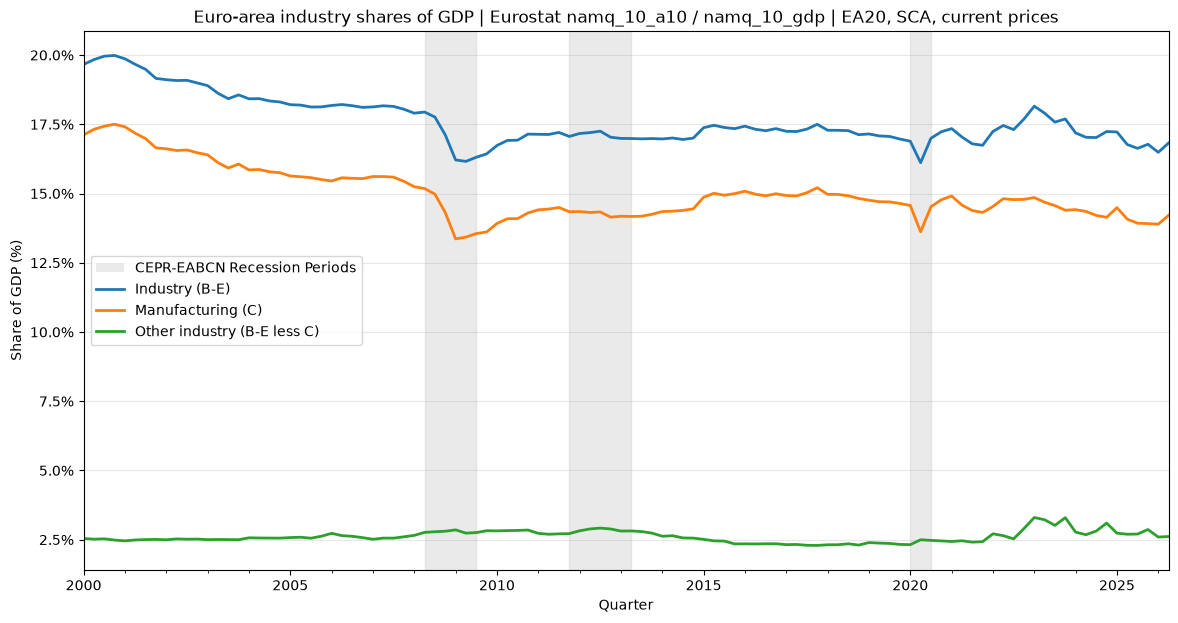

In [7]:
ax = industry_shares.plot(figsize=(14, 7), linewidth=2)
add_recession_shading(ax, recessions, label='CEPR-EABCN Recession Periods')
ax.set(
    title=f'{geo_label} industry shares of GDP | Eurostat namq_10_a10 / namq_10_gdp | {geo_code}, SCA, current prices',
    xlabel='Quarter',
    ylabel='Share of GDP (%)',
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='y', alpha=0.3)
plt.show()

In [8]:
latest_share = industry_shares.iloc[-1]
latest_quarter = industry_shares.index[-1].to_period('Q')
display(Markdown(
    f"**Interpretation.** In {latest_quarter}, industry represented "
    f"{latest_share['Industry (B-E)']:.1%} of {geo_code} GDP, including "
    f"{latest_share['Manufacturing (C)']:.1%} from manufacturing and "
    f"{latest_share['Other industry (B-E less C)']:.1%} from other industrial activities."
))

**Interpretation.** In 2026Q2, industry represented 16.8% of EA20 GDP, including 14.2% from manufacturing and 2.6% from other industrial activities.

## 2. Industrial production levels

Eurostat's `sts_inpr_m` production-volume series are seasonally and calendar adjusted (`SCA`) indices with 2021=100. Index levels are not divided by 100. Broad components are plotted separately because their weights are not supplied here and the indices are not additive.

In [9]:
production_codes = [
    'B-D', 'B', 'C', 'D',
    'MIG_ING', 'MIG_CAG', 'MIG_NRG_X_E', 'MIG_DCOG', 'MIG_NDCOG',
]
production_labels = {
    'B-D': 'Total industry',
    'B': 'Mining and quarrying',
    'C': 'Manufacturing',
    'D': 'Electricity, gas, steam and air conditioning',
    'MIG_ING': 'Intermediate goods',
    'MIG_CAG': 'Capital goods',
    'MIG_NRG_X_E': 'Energy',
    'MIG_DCOG': 'Durable consumer goods',
    'MIG_NDCOG': 'Non-durable consumer goods',
}

# I21 is an industrial production volume index with 2021=100.
production_raw = eurostat.get_data_df('sts_inpr_m', filter_pars={
    'startPeriod': report_start,
    'freq': 'M',
    's_adj': 'SCA',
    'unit': 'I21',
    'nace_r2': production_codes,
    'geo': geo_code,
})

geo_column = next(column for column in production_raw.columns if str(column).startswith('geo'))
expected_dimensions = {'PRD', 'SCA', 'I21', geo_code}
returned_dimensions = {
    production_raw['indic_bt'].iloc[0],
    production_raw['s_adj'].iloc[0],
    production_raw['unit'].iloc[0],
    production_raw[geo_column].iloc[0],
} if not production_raw.empty else set()
if returned_dimensions != expected_dimensions:
    raise ValueError(f'Unexpected Eurostat dimensions: {returned_dimensions}')
if set(production_raw['nace_r2']) != set(production_codes):
    missing_codes = set(production_codes) - set(production_raw['nace_r2'])
    raise ValueError(f'Eurostat omitted required production series: {sorted(missing_codes)}')

production = reshape_eurostat(production_raw, 'nace_r2', 'M')[production_codes]
production = production.rename(columns=production_labels)
latest_observations(production).assign(Value=lambda frame: frame['Value'].round(1))

,Observation,Value
Series,,
Total industry,2026-07-01,98.4
Mining and quarrying,2026-07-01,80.9
Manufacturing,2026-07-01,98.7
"Electricity, gas, steam and air conditioning",2026-07-01,97.2
Intermediate goods,2026-07-01,88.4
Capital goods,2026-07-01,103.7
Energy,2026-07-01,96.5
Durable consumer goods,2026-07-01,93.3
Non-durable consumer goods,2026-07-01,108.5


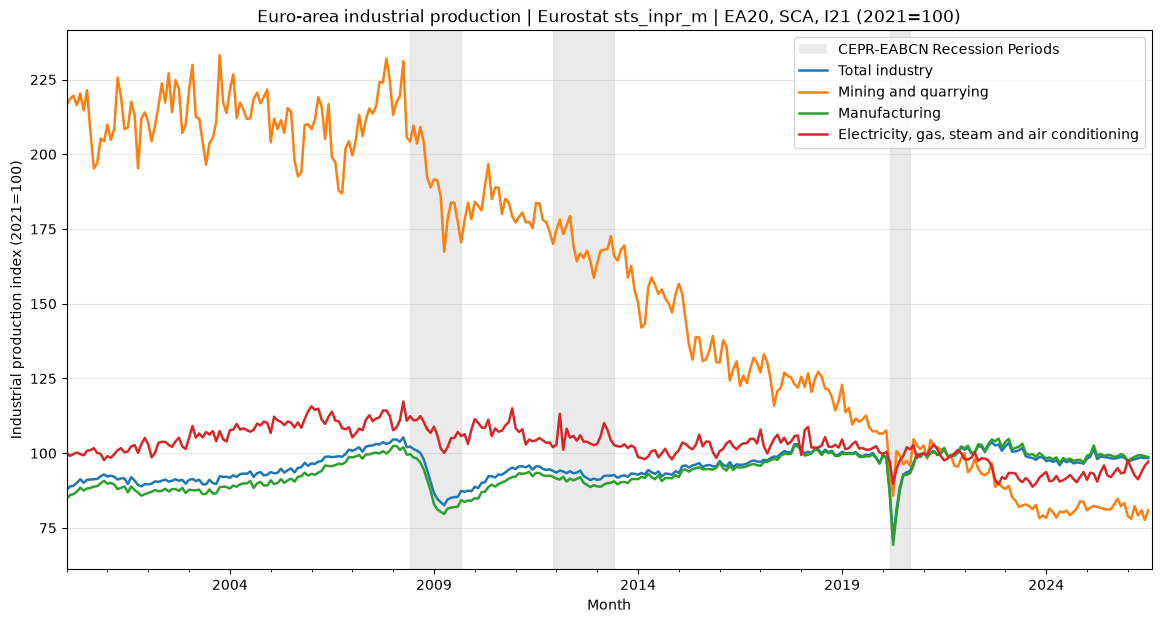

In [10]:
broad_components = [
    'Total industry',
    'Mining and quarrying',
    'Manufacturing',
    'Electricity, gas, steam and air conditioning',
]
ax = production[broad_components].plot(figsize=(14, 7), linewidth=1.8)
add_recession_shading(ax, recessions, label='CEPR-EABCN Recession Periods')
ax.set(
    title=f'{geo_label} industrial production | Eurostat sts_inpr_m | {geo_code}, SCA, I21 (2021=100)',
    xlabel='Month',
    ylabel='Industrial production index (2021=100)',
)
ax.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
level_latest = latest_observations(production[broad_components])
highest_level = level_latest['Value'].idxmax()
lowest_level = level_latest['Value'].idxmin()
display(Markdown(
    f"**Interpretation.** At their latest available observations, {highest_level} had the highest "
    f"index level ({level_latest.loc[highest_level, 'Value']:.1f}), while {lowest_level} had the lowest "
    f"({level_latest.loc[lowest_level, 'Value']:.1f}). These levels compare each series with its own 2021 base, "
    "not the absolute size of one industry with another."
))

**Interpretation.** At their latest available observations, Manufacturing had the highest index level (98.7), while Mining and quarrying had the lowest (80.9). These levels compare each series with its own 2021 base, not the absolute size of one industry with another.

## 3. Growth rates

Year-over-year growth compares each monthly index with the same month one year earlier using `pct_change(12)`. Missing observations remain missing.

In [12]:
production_yoy = production.pct_change(12, fill_method=None)
production_yoy.index = pd.DatetimeIndex(production_yoy.index, freq='MS')
latest_yoy = latest_observations(production_yoy[broad_components])
latest_yoy.rename(columns={'Value': 'YoY growth'}).style.format({
    'Observation': '{:%Y-%m}',
    'YoY growth': '{:+.1%}',
})

,Observation,YoY growth
Series,,
Total industry,2026-07,-0.2%
Mining and quarrying,2026-07,-0.4%
Manufacturing,2026-07,-0.7%
"Electricity, gas, steam and air conditioning",2026-07,+5.0%


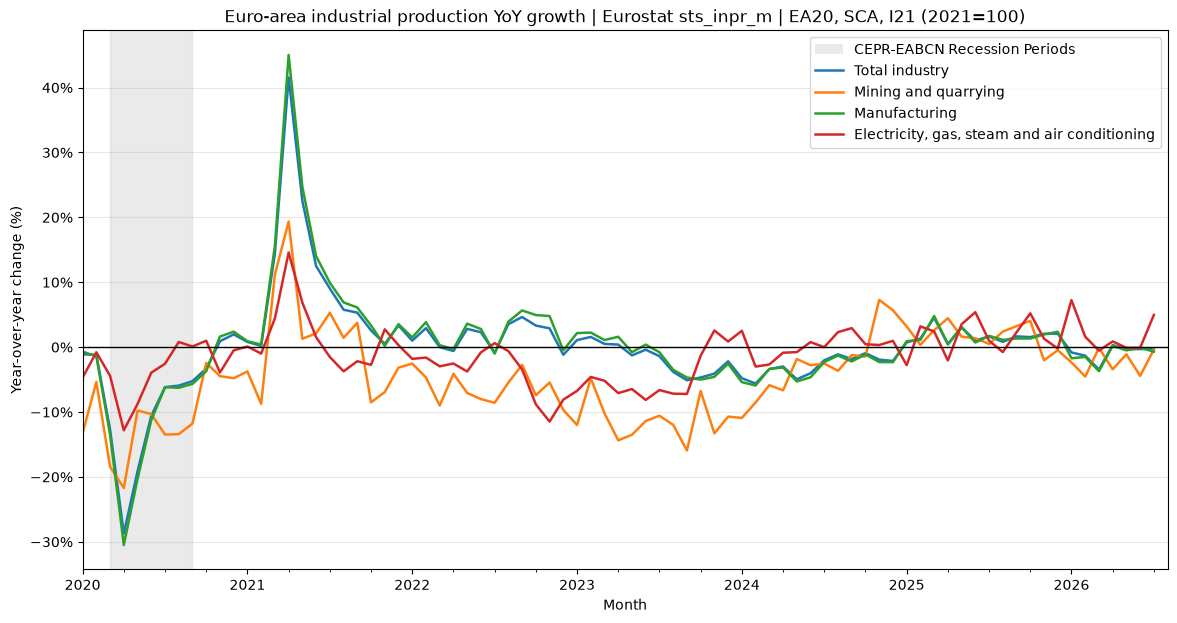

In [13]:
ax = production_yoy.loc['2020':, broad_components].plot(figsize=(14, 7), linewidth=1.8)
add_recession_shading(ax, recessions, label='CEPR-EABCN Recession Periods')
ax.axhline(0, color='black', linewidth=1)
ax.set(
    title=f'{geo_label} industrial production YoY growth | Eurostat sts_inpr_m | {geo_code}, SCA, I21 (2021=100)',
    xlabel='Month',
    ylabel='Year-over-year change (%)',
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
growing = latest_yoy.index[latest_yoy['Value'] > 0].tolist()
contracting = latest_yoy.index[latest_yoy['Value'] < 0].tolist()
display(Markdown(
    "**Interpretation.** Latest YoY readings show growth in "
    + (', '.join(growing) if growing else 'none of the broad components')
    + " and contraction in "
    + (', '.join(contracting) if contracting else 'none of the broad components')
    + ". Observation dates are reported in the table because Eurostat release timing can differ by series."
))

**Interpretation.** Latest YoY readings show growth in Electricity, gas, steam and air conditioning and contraction in Total industry, Mining and quarrying, Manufacturing. Observation dates are reported in the table because Eurostat release timing can differ by series.

## 4. Annual and YTD performance

Full-year growth is calculated from complete calendar-year averages. The current-year comparison uses only months available in both the current and previous year, preventing an incomplete YTD period from being compared with a full year.

In [15]:
annual_means = production[broad_components].resample('YE').mean()
annual_counts = production[broad_components].resample('YE').count()
complete_years = annual_counts.eq(12)
annual_growth = annual_means.pct_change(fill_method=None).where(complete_years & complete_years.shift(1))
annual_growth.index = annual_growth.index.year
annual_growth.index.name = 'Calendar year'
annual_growth.columns.name = None
annual_growth.dropna(how='all').tail(10).style.format('{:+.1%}')

,Total industry,Mining and quarrying,Manufacturing,"Electricity, gas, steam and air conditioning"
Calendar year,,,,
2016,+1.0%,-7.0%,+1.1%,+0.5%
2017,+3.2%,-3.4%,+3.5%,+1.3%
2018,+0.8%,-2.0%,+1.1%,-1.0%
2019,-1.0%,-8.8%,-0.9%,-1.1%
2020,-7.6%,-10.9%,-8.0%,-3.4%
2021,+8.9%,+0.7%,+9.7%,+1.5%
2022,+1.7%,-6.2%,+2.4%,-3.8%
2023,-1.6%,-11.3%,-1.2%,-4.9%
2024,-3.0%,-2.9%,-3.3%,+0.2%


In [16]:
current_ytd = ytd_table(production[broad_components], report_end.year)
current_ytd.style.format({
    'Growth': '{:+.1%}',
    'Through': lambda value: value.strftime('%Y-%m') if pd.notna(value) else 'Unavailable',
    'Months': '{:.0f}',
})

,Growth,Through,Months,Status
Total industry,-0.9%,2026-07,7,Incomplete YTD
Mining and quarrying,-2.3%,2026-07,7,Incomplete YTD
Manufacturing,-1.2%,2026-07,7,Incomplete YTD
"Electricity, gas, steam and air conditioning",+2.0%,2026-07,7,Incomplete YTD


In [17]:
available_ytd = current_ytd['Growth'].dropna()
if available_ytd.empty:
    display(Markdown(f"**Interpretation.** No like-for-like {report_end.year} YTD comparison is available."))
else:
    leader = available_ytd.idxmax()
    laggard = available_ytd.idxmin()
    through_month = current_ytd.loc[leader, 'Through']
    display(Markdown(
        f"**Interpretation.** Through {through_month:%B %Y}, {leader} had the strongest like-for-like YTD "
        f"change ({available_ytd[leader]:+.1%}), while {laggard} had the weakest ({available_ytd[laggard]:+.1%}). "
        f"The table marks the {report_end.year} comparison as incomplete until all 12 months are available."
    ))

**Interpretation.** Through July 2026, Electricity, gas, steam and air conditioning had the strongest like-for-like YTD change (+2.0%), while Mining and quarrying had the weakest (-2.3%). The table marks the 2026 comparison as incomplete until all 12 months are available.

## 5. Main industrial groupings

Main industrial groupings classify production by use. Current YoY and YTD rates are ranked below. Five- and ten-year comparisons use rolling 12-month averages to reduce sensitivity to a single month's volatility.

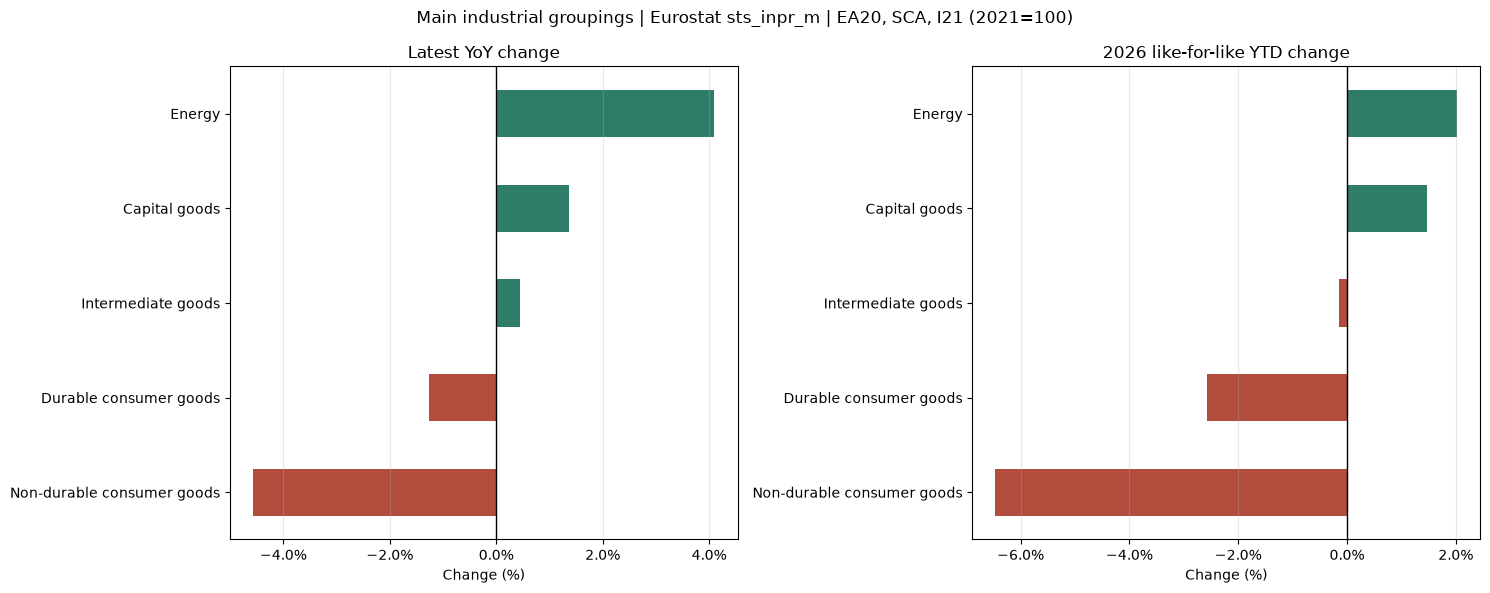

In [18]:
mig_columns = [
    'Intermediate goods',
    'Capital goods',
    'Energy',
    'Durable consumer goods',
    'Non-durable consumer goods',
]
mig_yoy = latest_observations(production_yoy[mig_columns])['Value']
mig_ytd = ytd_table(production[mig_columns], report_end.year)['Growth']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, values, title in [
    (axes[0], mig_yoy.sort_values(), 'Latest YoY change'),
    (axes[1], mig_ytd.sort_values(), f'{report_end.year} like-for-like YTD change'),
]:
    colors = ['#b24c3d' if value < 0 else '#2f7d68' for value in values]
    values.plot.barh(ax=axis, color=colors)
    axis.axvline(0, color='black', linewidth=1)
    axis.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    axis.set(title=title, xlabel='Change (%)', ylabel='')
    axis.grid(axis='x', alpha=0.3)
fig.suptitle(f'Main industrial groupings | Eurostat sts_inpr_m | {geo_code}, SCA, I21 (2021=100)')
fig.tight_layout()
plt.show()

In [19]:
mig_rolling = production[mig_columns].rolling(12, min_periods=12).mean()
horizon_changes = {}
for column in mig_columns:
    series = mig_rolling[column].dropna()
    latest_date = series.index[-1]
    horizon_changes[column] = {}
    for years in (5, 10):
        comparison_date = latest_date - pd.DateOffset(years=years)
        prior_value = series.get(comparison_date, float('nan'))
        horizon_changes[column][f'{years}-year change'] = series.iloc[-1] / prior_value - 1

horizon_changes = pd.DataFrame(horizon_changes).T
horizon_changes.style.format('{:+.1%}', na_rep='Unavailable')

,5-year change,10-year change
Intermediate goods,-10.4%,-8.0%
Capital goods,+4.2%,+6.1%
Energy,-6.2%,-11.8%
Durable consumer goods,-6.1%,+0.8%
Non-durable consumer goods,+11.6%,+18.4%


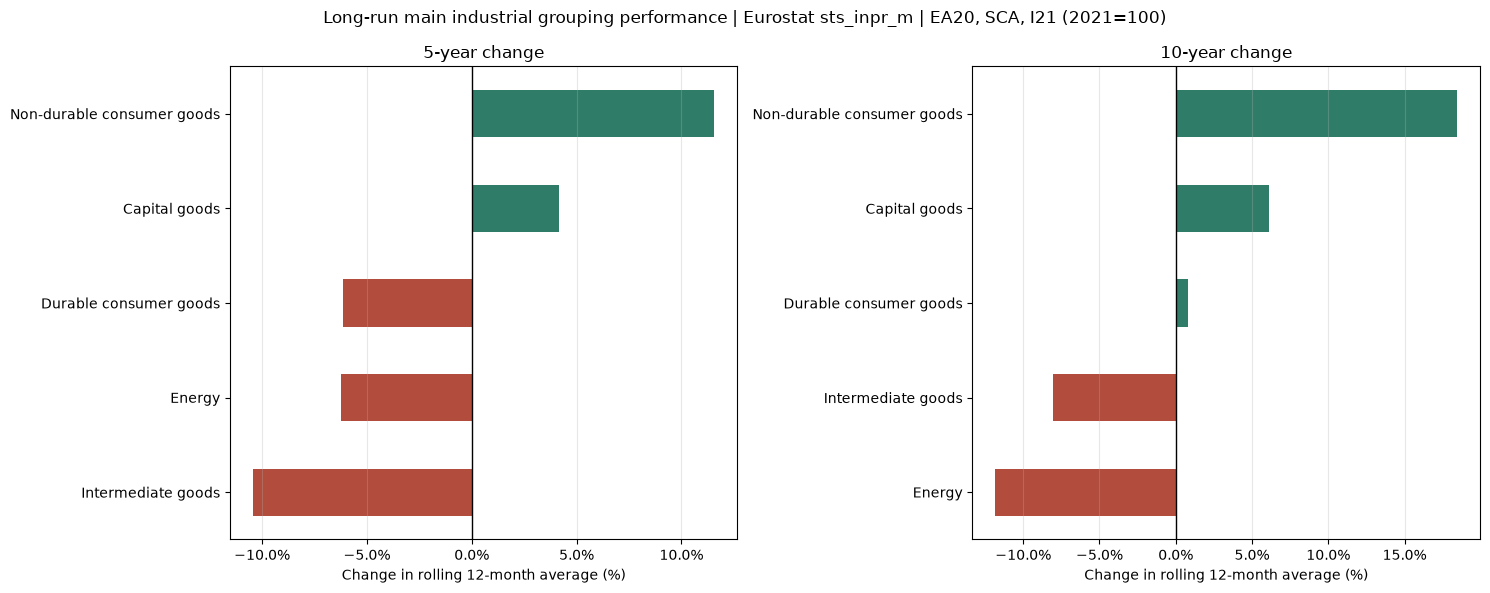

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, column in zip(axes, horizon_changes.columns):
    values = horizon_changes[column].dropna().sort_values()
    colors = ['#b24c3d' if value < 0 else '#2f7d68' for value in values]
    values.plot.barh(ax=axis, color=colors)
    axis.axvline(0, color='black', linewidth=1)
    axis.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    axis.set(title=column, xlabel='Change in rolling 12-month average (%)', ylabel='')
    axis.grid(axis='x', alpha=0.3)
fig.suptitle(f'Long-run main industrial grouping performance | Eurostat sts_inpr_m | {geo_code}, SCA, I21 (2021=100)')
fig.tight_layout()
plt.show()

In [21]:
mig_current = mig_ytd.dropna()
mig_long = horizon_changes['10-year change'].dropna()
display(Markdown(
    f"**Interpretation.** {mig_current.idxmax()} leads the current like-for-like YTD ranking "
    f"at {mig_current.max():+.1%}, while {mig_current.idxmin()} ranks last at {mig_current.min():+.1%}. "
    f"Over ten years, using rolling annual averages, {mig_long.idxmax()} performed best "
    f"({mig_long.max():+.1%}) and {mig_long.idxmin()} performed worst ({mig_long.min():+.1%})."
))

**Interpretation.** Energy leads the current like-for-like YTD ranking at +2.0%, while Non-durable consumer goods ranks last at -6.5%. Over ten years, using rolling annual averages, Non-durable consumer goods performed best (+18.4%) and Energy performed worst (-11.8%).

## 6. Manufacturing detail

Eurostat manufacturing divisions `C10` through `C33` are requested together. A division is omitted only when the provider returns no usable observations; any omission is reported explicitly. Rankings use each division's like-for-like current-year average.

In [22]:
division_codes = [f'C{number}' for number in range(10, 34)]
division_names = dict(eurostat.get_dic('sts_inpr_m', 'nace_r2'))

manufacturing_raw = eurostat.get_data_df('sts_inpr_m', filter_pars={
    'startPeriod': report_start,
    'freq': 'M',
    's_adj': 'SCA',
    'unit': 'I21',
    'nace_r2': division_codes,
    'geo': geo_code,
})
manufacturing = reshape_eurostat(manufacturing_raw, 'nace_r2', 'M')
usable_divisions = [code for code in division_codes if code in manufacturing and manufacturing[code].notna().any()]
omitted_divisions = [code for code in division_codes if code not in usable_divisions]
manufacturing = manufacturing[usable_divisions].rename(
    columns={code: f'{code} — {division_names[code]}' for code in usable_divisions}
)

if manufacturing.empty:
    raise ValueError('Eurostat returned no usable manufacturing divisions')
omitted_text = ', '.join(f'{code} — {division_names.get(code, code)}' for code in omitted_divisions) or 'None'
display(Markdown(f'**Omitted divisions with no usable observations:** {omitted_text}.'))

**Omitted divisions with no usable observations:** None.

In [23]:
manufacturing_ytd = ytd_table(manufacturing, report_end.year)
manufacturing_ranking = manufacturing_ytd.dropna(subset=['Growth']).sort_values('Growth')
if manufacturing_ranking.empty:
    raise ValueError(f'No manufacturing division has a usable {report_end.year} YTD comparison')
manufacturing_ranking.style.format({
    'Growth': '{:+.1%}',
    'Through': lambda value: value.strftime('%Y-%m') if pd.notna(value) else 'Unavailable',
    'Months': '{:.0f}',
})

,Growth,Through,Months,Status
C21 — Manufacture of basic pharmaceutical products and pharmaceutical preparations,-14.7%,2026-07,7,Incomplete YTD
C12 — Manufacture of tobacco products,-7.7%,2026-07,7,Incomplete YTD
C32 — Other manufacturing,-6.3%,2026-07,7,Incomplete YTD
C14 — Manufacture of wearing apparel,-5.7%,2026-07,7,Incomplete YTD
"C29 — Manufacture of motor vehicles, trailers and semi-trailers",-4.1%,2026-07,7,Incomplete YTD
C15 — Manufacture of leather and related products,-3.7%,2026-07,7,Incomplete YTD
C13 — Manufacture of textiles,-3.5%,2026-07,7,Incomplete YTD
C31 — Manufacture of furniture,-3.5%,2026-07,7,Incomplete YTD
"C16 — Manufacture of wood and of products of wood and cork, except furniture; manufacture of articles of straw and plaiting materials",-2.5%,2026-07,7,Incomplete YTD
C20 — Manufacture of chemicals and chemical products,-2.4%,2026-07,7,Incomplete YTD


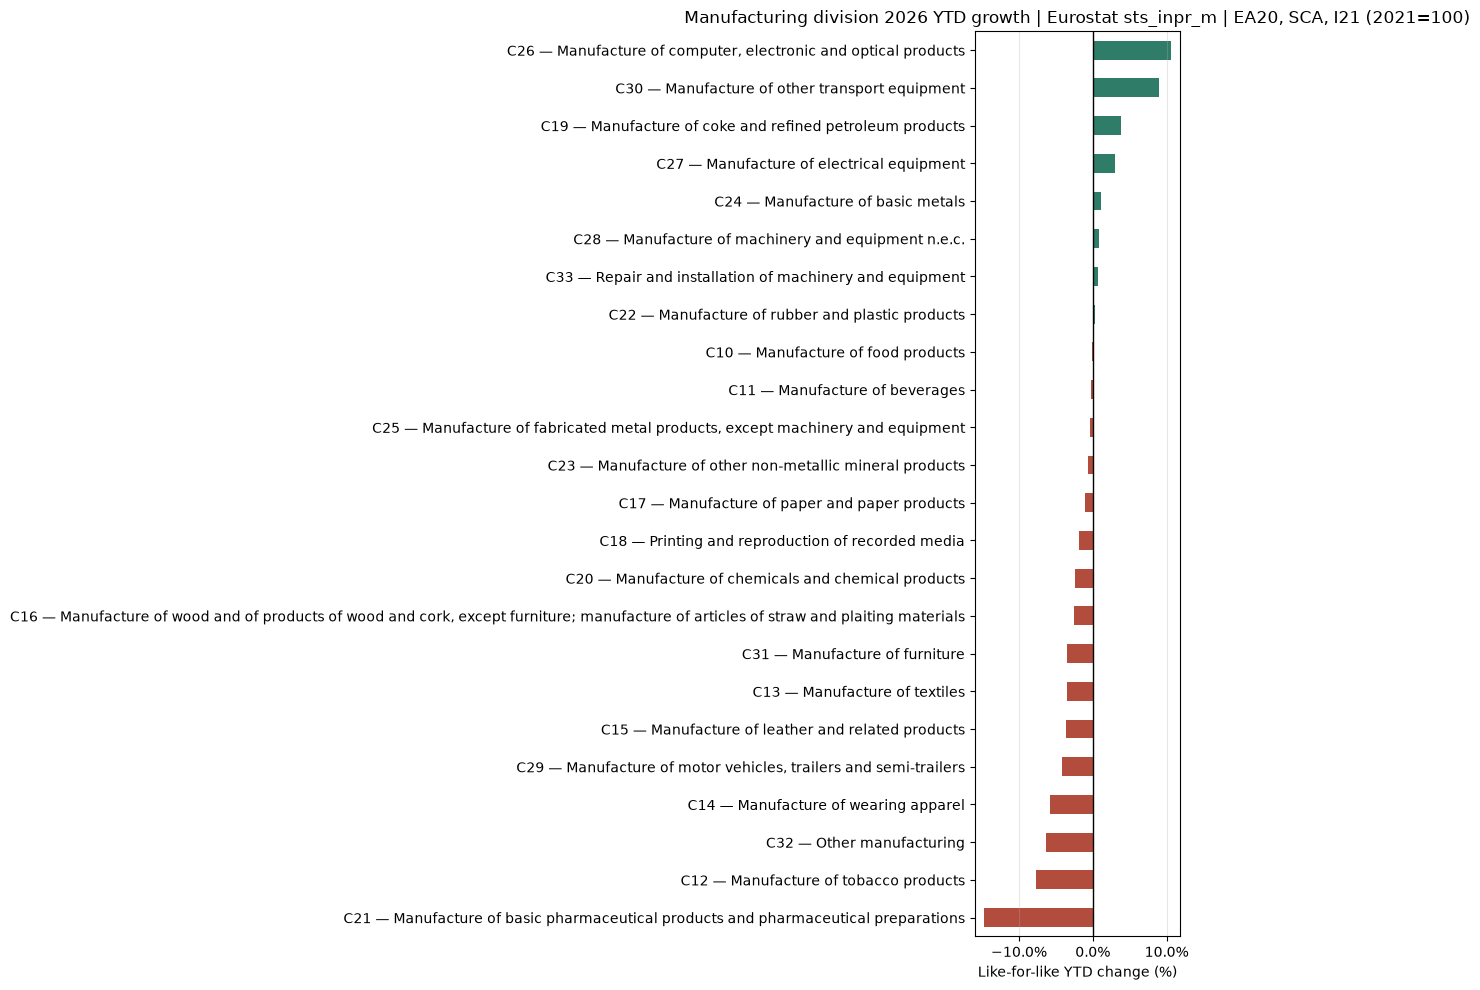

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))
division_growth = manufacturing_ranking['Growth']
colors = ['#b24c3d' if value < 0 else '#2f7d68' for value in division_growth]
division_growth.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(
    title=f'Manufacturing division {report_end.year} YTD growth | Eurostat sts_inpr_m | EA20, SCA, I21 (2021=100)',
    xlabel='Like-for-like YTD change (%)',
    ylabel='',
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
division_leader = manufacturing_ranking['Growth'].idxmax()
division_laggard = manufacturing_ranking['Growth'].idxmin()
display(Markdown(
    f"**Interpretation.** {division_leader} has the strongest available {report_end.year} YTD change "
    f"({manufacturing_ranking.loc[division_leader, 'Growth']:+.1%}), while {division_laggard} has the weakest "
    f"({manufacturing_ranking.loc[division_laggard, 'Growth']:+.1%}). The ranking includes "
    f"{len(manufacturing_ranking)} usable divisions and omits {len(omitted_divisions)} with no usable observations."
))

**Interpretation.** C26 — Manufacture of computer, electronic and optical products has the strongest available 2026 YTD change (+10.5%), while C21 — Manufacture of basic pharmaceutical products and pharmaceutical preparations has the weakest (-14.7%). The ranking includes 24 usable divisions and omits 0 with no usable observations.

## 7. Conclusions

The conclusion below is generated from the latest retrieved observations rather than fixed prose. It compares directions and rates, not contributions: Eurostat component weights would be required to attribute total-industry growth quantitatively.

In [26]:
component_growth = latest_yoy['Value']
manufacturing_growth = component_growth['Manufacturing']
other_components = component_growth.drop(index=['Total industry', 'Manufacturing'])
other_leader = other_components.idxmax()
direction = lambda value: 'growing' if value > 0 else 'contracting' if value < 0 else 'unchanged'

display(Markdown(
    f"**Latest assessment.** Total industry is {direction(component_growth['Total industry'])} "
    f"at {component_growth['Total industry']:+.1%} YoY. Manufacturing is "
    f"{direction(manufacturing_growth)} at {manufacturing_growth:+.1%}; among the other broad activities, "
    f"{other_leader} has the strongest latest rate at {other_components[other_leader]:+.1%}. "
    f"Manufacturing's rate is {'above' if manufacturing_growth > other_components.mean() else 'below'} the mean rate of "
    "mining and utilities. This comparison indicates where momentum is strongest, but it does not assign contributions "
    "to the total because verified Eurostat component weights are not used."
))

**Latest assessment.** Total industry is contracting at -0.2% YoY. Manufacturing is contracting at -0.7%; among the other broad activities, Electricity, gas, steam and air conditioning has the strongest latest rate at +5.0%. Manufacturing's rate is below the mean rate of mining and utilities. This comparison indicates where momentum is strongest, but it does not assign contributions to the total because verified Eurostat component weights are not used.